# Project - Machine Learning

# Problem 1:
# You are hired by one of the leading news channel CNBE who wants to analyze recent elections. This survey was conducted on 1525 voters with 9 variables. You have to build a model, to predict which party a voter will vote for on the basis of the given information, to create an exit poll that will help in predicting overall win and seats covered by a particular party.

# Dataset for Problem: Election_Data.xlsx

In [1]:
!pip install xgboost

You are using pip version 9.0.1, however version 20.2 is available.
You should consider upgrading via the 'python -m pip install --upgrade pip' command.


In [108]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from scipy.stats import zscore
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
import xgboost as xgb
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, roc_curve, classification_report, confusion_matrix, accuracy_score

## Data Ingestion:

## 1. Read the dataset. Do the descriptive statistics and do null value condition check. Write an inference on it.

In [132]:
df1 = pd.read_excel('Election_Data.xlsx', 'Election_Dataset_Two Classes')

In [26]:
df1.head()

,Unnamed: 0,vote,age,economic.cond.national,economic.cond.household,Blair,Hague,Europe,political.knowledge,gender
0,1,Labour,43,3,3,4,1,2,2,female
1,2,Labour,36,4,4,4,4,5,2,male
2,3,Labour,35,4,4,5,2,3,2,male
3,4,Labour,24,4,2,2,1,4,0,female
4,5,Labour,41,2,2,1,1,6,2,male


In [27]:
df1.shape

(1525, 10)

In [28]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1525 entries, 0 to 1524
Data columns (total 10 columns):
Unnamed: 0                 1525 non-null int64
vote                       1525 non-null object
age                        1525 non-null int64
economic.cond.national     1525 non-null int64
economic.cond.household    1525 non-null int64
Blair                      1525 non-null int64
Hague                      1525 non-null int64
Europe                     1525 non-null int64
political.knowledge        1525 non-null int64
gender                     1525 non-null object
dtypes: int64(8), object(2)
memory usage: 119.2+ KB


In [29]:
df1.describe(include='all')

,Unnamed: 0,vote,age,economic.cond.national,economic.cond.household,Blair,Hague,Europe,political.knowledge,gender
count,1525.000000,1525,1525.000000,1525.000000,1525.000000,1525.000000,1525.000000,1525.000000,1525.000000,1525
unique,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,NaN,Labour,NaN,NaN,NaN,NaN,NaN,NaN,NaN,female
freq,NaN,1063,NaN,NaN,NaN,NaN,NaN,NaN,NaN,812
mean,763.000000,NaN,54.182295,3.245902,3.140328,3.334426,2.746885,6.728525,1.542295,NaN
std,440.373894,NaN,15.711209,0.880969,0.929951,1.174824,1.230703,3.297538,1.083315,NaN
min,1.000000,NaN,24.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,NaN
25%,382.000000,NaN,41.000000,3.000000,3.000000,2.000000,2.000000,4.000000,0.000000,NaN
50%,763.000000,NaN,53.000000,3.000000,3.000000,4.000000,2.000000,6.000000,2.000000,NaN
75%,1144.000000,NaN,67.000000,4.000000,4.000000,4.000000,4.000000,10.000000,2.000000,NaN


In [30]:
df1.isna().sum()

Unnamed: 0                 0
vote                       0
age                        0
economic.cond.national     0
economic.cond.household    0
Blair                      0
Hague                      0
Europe                     0
political.knowledge        0
gender                     0
dtype: int64

In [31]:
dups = df1.duplicated().sum()
dups

0

In [32]:
df1.dtypes

Unnamed: 0                  int64
vote                       object
age                         int64
economic.cond.national      int64
economic.cond.household     int64
Blair                       int64
Hague                       int64
Europe                      int64
political.knowledge         int64
gender                     object
dtype: object

In [33]:
df1.quantile(0.75)-df1.quantile(0.25)

Unnamed: 0                 762.0
age                         26.0
economic.cond.national       1.0
economic.cond.household      1.0
Blair                        2.0
Hague                        2.0
Europe                       6.0
political.knowledge          2.0
dtype: float64

In [34]:
df1.var()

Unnamed: 0                 193929.166667
age                           246.842075
economic.cond.national          0.776107
economic.cond.household         0.864810
Blair                           1.380212
Hague                           1.514631
Europe                         10.873759
political.knowledge             1.173571
dtype: float64

In [35]:
df1.skew()

Unnamed: 0                 0.000000
age                        0.144621
economic.cond.national    -0.240453
economic.cond.household   -0.149552
Blair                     -0.535419
Hague                      0.152100
Europe                    -0.135947
political.knowledge       -0.426838
dtype: float64

## 2. Perform Univariate and Bivariate Analysis. Do exploratory data analysis. Check for Outliers.

(array([1, 2, 3, 4, 5, 6, 7, 8]), <a list of 8 Text xticklabel objects>)

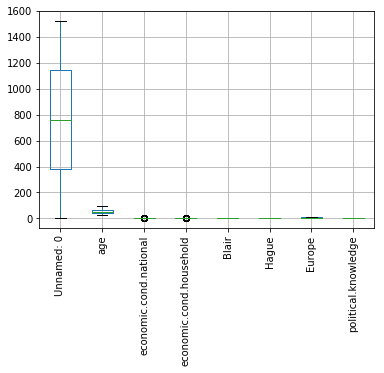

In [36]:
df1.boxplot()
plt.xticks(rotation=90)

array([[<matplotlib.axes._subplots.AxesSubplot object at 0x0000000FEA9C9EB8>,
      dtype=object)

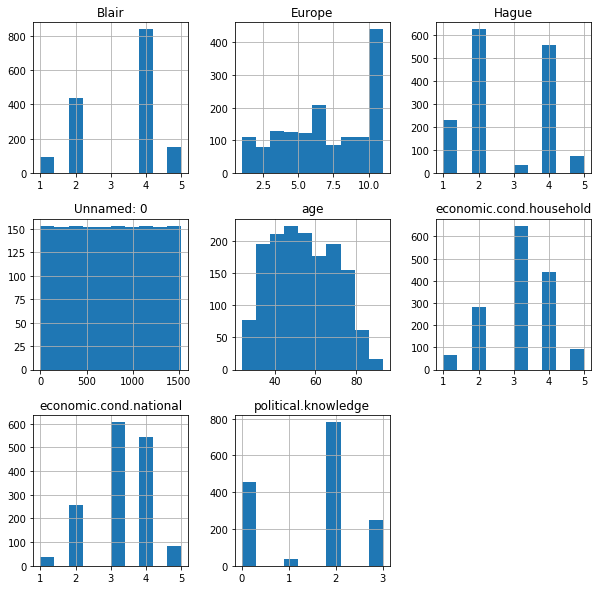

In [37]:
df1.hist(figsize=(10,10))

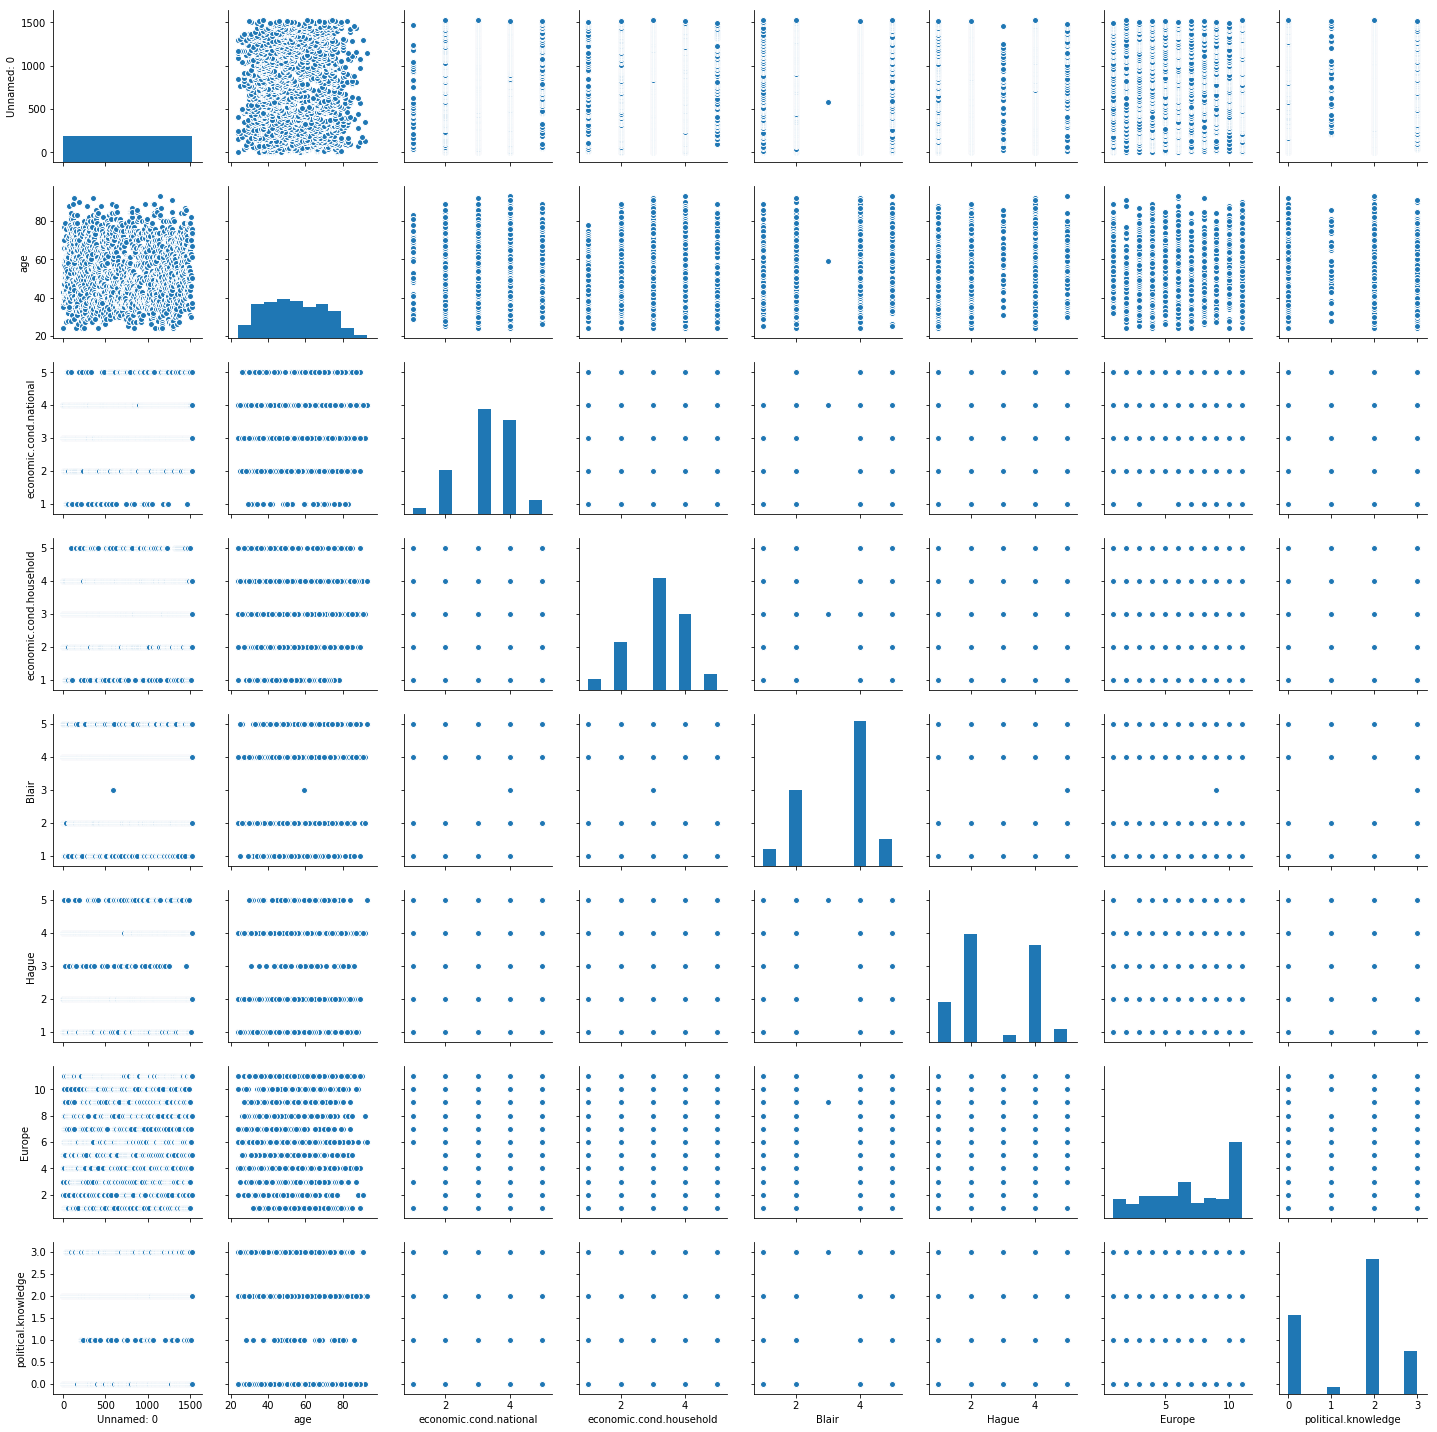

In [38]:
sns.pairplot(df1)

In [39]:
df1.cov()

,Unnamed: 0,age,economic.cond.national,economic.cond.household,Blair,Hague,Europe,political.knowledge
Unnamed: 0,193929.166667,35.476378,27.887139,14.704724,0.828740,0.152887,55.498688,1.185696
age,35.476378,246.842075,0.256981,-0.607619,0.557762,0.669531,3.568550,-0.825301
economic.cond.national,27.887139,0.256981,0.776107,0.283712,0.338314,-0.216589,-0.608397,-0.022546
economic.cond.household,14.704724,-0.607619,0.283712,0.864810,0.235192,-0.116689,-0.352299,-0.038091
Blair,0.828740,0.557762,0.338314,0.235192,1.380212,-0.351648,-1.147341,-0.026621
Hague,0.152887,0.669531,-0.216589,-0.116689,-0.351648,1.514631,1.166149,-0.040469
Europe,55.498688,3.568550,-0.608397,-0.352299,-1.147341,1.166149,10.873759,-0.544285
political.knowledge,1.185696,-0.825301,-0.022546,-0.038091,-0.026621,-0.040469,-0.544285,1.173571


In [40]:
df1.corr()

,Unnamed: 0,age,economic.cond.national,economic.cond.household,Blair,Hague,Europe,political.knowledge
Unnamed: 0,1.000000,0.005128,0.071882,0.035907,0.001602,0.000282,0.038218,0.002485
age,0.005128,1.000000,0.018567,-0.041587,0.030218,0.034626,0.068880,-0.048490
economic.cond.national,0.071882,0.018567,1.000000,0.346303,0.326878,-0.199766,-0.209429,-0.023624
economic.cond.household,0.035907,-0.041587,0.346303,1.000000,0.215273,-0.101956,-0.114885,-0.037810
Blair,0.001602,0.030218,0.326878,0.215273,1.000000,-0.243210,-0.296162,-0.020917
Hague,0.000282,0.034626,-0.199766,-0.101956,-0.243210,1.000000,0.287350,-0.030354
Europe,0.038218,0.068880,-0.209429,-0.114885,-0.296162,0.287350,1.000000,-0.152364
political.knowledge,0.002485,-0.048490,-0.023624,-0.037810,-0.020917,-0.030354,-0.152364,1.000000


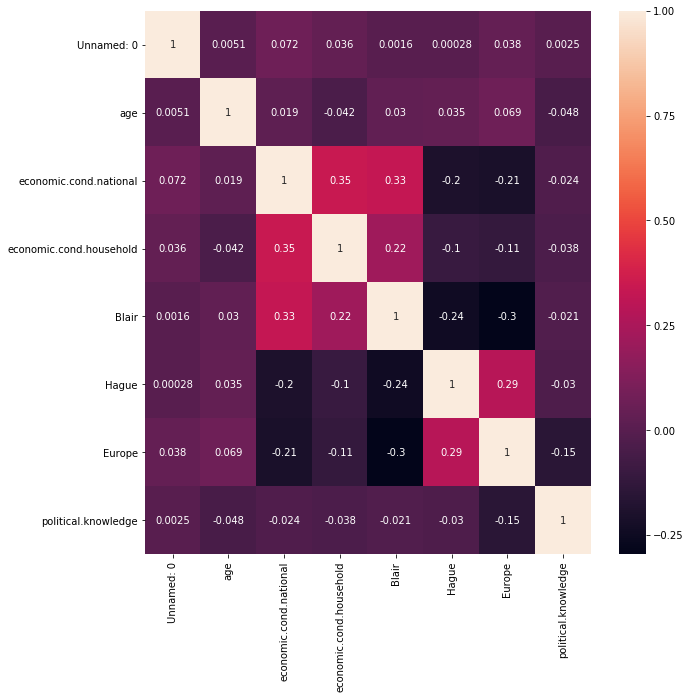

In [41]:
plt.figure(figsize=(10,10))
sns.heatmap(df1.corr(), annot = True)

## Data Preparation:

## 1. Encode the data (having string values) for Modelling. Is Scaling necessary here or not? Data Split: Split the data into train and test (70:30).

In [133]:
df1.drop('Unnamed: 0', axis = 1, inplace = True)

In [134]:
df1.head()

,vote,age,economic.cond.national,economic.cond.household,Blair,Hague,Europe,political.knowledge,gender
0,Labour,43,3,3,4,1,2,2,female
1,Labour,36,4,4,4,4,5,2,male
2,Labour,35,4,4,5,2,3,2,male
3,Labour,24,4,2,2,1,4,0,female
4,Labour,41,2,2,1,1,6,2,male


In [135]:
df1.shape

(1525, 9)

In [136]:
x = df1.drop('vote', axis = 1)
y = df1.pop('vote')

In [137]:
features_to_normalize = ['age']
x[features_to_normalize] = x[features_to_normalize].apply(lambda x:(x-x.min()) / (x.max()-x.min()))

In [138]:
x[['economic.cond.national','economic.cond.household','Blair','Hague','Europe','political.knowledge','gender']]= (x[['economic.cond.national','economic.cond.household','Blair','Hague','Europe','political.knowledge','gender']]).astype("object")

In [139]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1525 entries, 0 to 1524
Data columns (total 8 columns):
age                        1525 non-null float64
economic.cond.national     1525 non-null object
economic.cond.household    1525 non-null object
Blair                      1525 non-null object
Hague                      1525 non-null object
Europe                     1525 non-null object
political.knowledge        1525 non-null object
gender                     1525 non-null object
dtypes: float64(1), object(7)
memory usage: 95.4+ KB


In [140]:
x = pd.get_dummies(x, prefix_sep='_', drop_first=True)

In [141]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1525 entries, 0 to 1524
Data columns (total 31 columns):
age                          1525 non-null float64
economic.cond.national_2     1525 non-null uint8
economic.cond.national_3     1525 non-null uint8
economic.cond.national_4     1525 non-null uint8
economic.cond.national_5     1525 non-null uint8
economic.cond.household_2    1525 non-null uint8
economic.cond.household_3    1525 non-null uint8
economic.cond.household_4    1525 non-null uint8
economic.cond.household_5    1525 non-null uint8
Blair_2                      1525 non-null uint8
Blair_3                      1525 non-null uint8
Blair_4                      1525 non-null uint8
Blair_5                      1525 non-null uint8
Hague_2                      1525 non-null uint8
Hague_3                      1525 non-null uint8
Hague_4                      1525 non-null uint8
Hague_5                      1525 non-null uint8
Europe_2                     1525 non-null uint8
Europe_3 

In [142]:
x.head()

,age,economic.cond.national_2,economic.cond.national_3,economic.cond.national_4,economic.cond.national_5,economic.cond.household_2,economic.cond.household_3,economic.cond.household_4,economic.cond.household_5,Blair_2,...,Europe_6,Europe_7,Europe_8,Europe_9,Europe_10,Europe_11,political.knowledge_1,political.knowledge_2,political.knowledge_3,gender_male
0,0.275362,0,1,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,0.173913,0,0,1,0,0,0,1,0,0,...,0,0,0,0,0,0,0,1,0,1
2,0.159420,0,0,1,0,0,0,1,0,0,...,0,0,0,0,0,0,0,1,0,1
3,0.000000,0,0,1,0,1,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
4,0.246377,1,0,0,0,1,0,0,0,0,...,1,0,0,0,0,0,0,1,0,1


In [143]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=.30, random_state=0)

In [144]:
print('X_train',X_train.shape)
print('X_test',X_test.shape)
print('y_train',y_train.shape)
print('y_test',y_test.shape)

X_train (1067, 31)
X_test (458, 31)
y_train (1067,)
y_test (458,)


## Modelling:

## 1. Apply Logistic Regression and LDA (linear discriminant analysis).

### Logistic Regression

In [145]:
Logit_model = LogisticRegression()
Logit_model.fit(X_train, y_train)

LogisticRegression()

In [146]:
y_train_predict_logit = Logit_model.predict(X_train)
y_test_predict_logit = Logit_model.predict(X_test)

### Linear Discriminant Analysis

In [99]:
LDA_model = LinearDiscriminantAnalysis()
LDA_model.fit(X_train, y_train)

LinearDiscriminantAnalysis()

In [100]:
y_train_predict_LDA = LDA_model.predict(X_train)
y_test_predict_LDA = LDA_model.predict(X_test)

## 2. Apply KNN Model, Naïve Bayes Model and support vector machine (SVM) model. Interpret the results.

### KNN

In [101]:
KNN_model = KNeighborsClassifier()
KNN_model.fit(X_train, y_train)

KNeighborsClassifier()

In [102]:
y_train_predict_KNN = KNN_model.predict(X_train)
y_test_predict_KNN = KNN_model.predict(X_test)

### Naive Bayes

In [103]:
NB_model = GaussianNB()
NB_model.fit(X_train, y_train)

GaussianNB()

In [104]:
y_train_predict_NB = NB_model.predict(X_train)
y_test_predict_NB = NB_model.predict(X_test)

### Support Vector Machine

In [105]:
SVM_model = svm.SVC()
SVM_model.fit(X_train, y_train)

SVC()

In [106]:
y_train_predict_SVM = SVM_model.predict(X_train)
y_test_predict_SVM = SVM_model.predict(X_test)

## 3. Model Tuning, Bagging (Random Forest should be applied for Bagging) and Boosting.

### Bagging (Random Forest) with Tuning parameters

In [110]:
param_grid_RFCL = {
    'max_depth': [8,10,12],
    'max_features': [12,18,24],
    'min_samples_leaf': [50,100,150],
    'min_samples_split': [150,300,450],
    'n_estimators': [300,500]
}

RF_model = RandomForestClassifier()

grid_search_RFCL = GridSearchCV(estimator = RF_model, param_grid = param_grid_RFCL, cv = 5)

In [111]:
grid_search_RFCL.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'max_depth': [8, 10, 12], 'max_features': [12, 18, 24],
                         'min_samples_leaf': [50, 100, 150],
                         'min_samples_split': [150, 300, 450],
                         'n_estimators': [300, 500]})

In [112]:
grid_search_RFCL.best_params_

{'max_depth': 12,
 'max_features': 12,
 'min_samples_leaf': 50,
 'min_samples_split': 150,
 'n_estimators': 500}

In [114]:
best_grid_RFCL = grid_search_RFCL.best_estimator_

In [115]:
best_grid_RFCL

RandomForestClassifier(max_depth=12, max_features=12, min_samples_leaf=50,
                       min_samples_split=150, n_estimators=500)

In [120]:
y_train_predict_RFCL = best_grid_RFCL.predict(X_train)
y_test_predict_RFCL = best_grid_RFCL.predict(X_test)

### Boosting with Tuning parameters

### XGBoost

In [116]:
XGB_model=xgb.XGBClassifier(random_state=1,learning_rate=0.01)
XGB_model.fit(X_train, y_train)

XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=1,
              colsample_bynode=1, colsample_bytree=1, gamma=0, gpu_id=-1,
              importance_type='gain', interaction_constraints='',
              learning_rate=0.01, max_delta_step=0, max_depth=6,
              min_child_weight=1, missing=nan, monotone_constraints='()',
              n_estimators=100, n_jobs=0, num_parallel_tree=1, random_state=1,
              reg_alpha=0, reg_lambda=1, scale_pos_weight=1, subsample=1,
              tree_method='exact', validate_parameters=1, verbosity=None)

In [117]:
y_train_predict_XGB = XGB_model.predict(X_train)
y_test_predict_XGB = XGB_model.predict(X_test)

### ADA Boost

In [118]:
ADB_model = AdaBoostClassifier(n_estimators=100,random_state=1)
ADB_model.fit(X_train,y_train)

AdaBoostClassifier(n_estimators=100, random_state=1)

In [119]:
y_train_predict_ADB = ADB_model.predict(X_train)
y_test_predict_ADB = ADB_model.predict(X_test)

## 4. Performance Metrics: Check the performance of Predictions on Train and Test sets using Accuracy, Confusion Matrix, Plot ROC curve and get ROC_AUC score for each model. Final Model: Compare the models and write inference which model is best/optimized.

### Performance Metrics for Logistic Regression:

In [151]:
print(accuracy_score(y_train, y_train_predict_logit))
print(accuracy_score(y_test, y_test_predict_logit)) 
print(confusion_matrix(y_train, y_train_predict_logit)) 
print(confusion_matrix(y_test, y_test_predict_logit)) 
print(classification_report(y_train, y_train_predict_logit))
print(classification_report(y_test, y_test_predict_logit))
print(roc_auc_score(y_train, Logit_model.predict_proba(X_train)[:,1]))
print(roc_auc_score(y_test, Logit_model.predict_proba(X_test)[:,1]))

0.851921274601687
0.8231441048034934
[[231  97]
 [ 61 678]]
[[ 90  44]
 [ 37 287]]
              precision    recall  f1-score   support

Conservative       0.79      0.70      0.75       328
      Labour       0.87      0.92      0.90       739

    accuracy                           0.85      1067
   macro avg       0.83      0.81      0.82      1067
weighted avg       0.85      0.85      0.85      1067

              precision    recall  f1-score   support

Conservative       0.71      0.67      0.69       134
      Labour       0.87      0.89      0.88       324

    accuracy                           0.82       458
   macro avg       0.79      0.78      0.78       458
weighted avg       0.82      0.82      0.82       458

0.9022946301858148
0.8813916528468767


In [153]:
fpr_log_reg_train, tpr_log_reg_train, tresholds_log_reg_train = roc_curve(y_train, Logit_model.predict_proba(X_train)[:,1]) 
plt.plot([0,1], [0,1], linestyle='--') 
plt.plot(fpr_log_reg_train, tpr_log_reg_train, marker='.')

ValueError: y_true takes value in {'Conservative', 'Labour'} and pos_label is not specified: either make y_true take value in {0, 1} or {-1, 1} or pass pos_label explicitly.

In [ ]:
fpr_log_reg_test, tpr_log_reg_test, tresholds_log_reg_test = roc_curve(y_test, Logit_model.predict_proba(x_test)[:,1]) 
plt.plot([0,1], [0,1], linestyle='--') 
plt.plot(fpr_log_reg_test, tpr_log_reg_test, marker='.')